In [7]:
import math
import torch
import time
import random
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.parameter import Parameter
from torch.nn import init
from torch import Tensor
from scipy.special import gamma 
import matplotlib.pyplot as plt

In [8]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath, amssymb}'
custom_params = {
    'font.size': 20,
    'lines.linewidth': 1,
    'axes.labelsize': 20,
    'axes.titlesize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
}

In [9]:
def get_memory_usage():
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated()/ (1024*1024)
    return 0

In [10]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [11]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [12]:
class Fractional_Order_Matrix_Differential_Solver(torch.autograd.Function):
    @staticmethod
    def forward(ctx,input1,w,b,alpha):
        alpha = torch.tensor(alpha)
        ctx.save_for_backward(input1,w,b,alpha)
        outputs = input1@w + b
        return outputs

    @staticmethod
    def backward(ctx, grad_outputs):
        input1,w,b,alpha = ctx.saved_tensors
        x_fractional, w_fractional = Fractional_Order_Matrix_Differential_Solver.Fractional_Order_Matrix_Differential_Linear(input1,w,b,alpha)   
        x_grad = torch.mm(grad_outputs,x_fractional)
        w_grad = torch.mm(w_fractional,grad_outputs)
        b_grad = grad_outputs.sum(dim=0)
        return x_grad, w_grad, b_grad,None

    @staticmethod
    def Fractional_Order_Matrix_Differential_Linear(xs,ws,b,alpha):
            if xs.dim() == 2:
                #w
                wf = ws[:,0].view(1,-1)
                #main
                w_main = torch.mul(xs,(torch.abs(wf)+1e-8)**(1-alpha)/gamma(2-alpha))
                #partial
                x_rows, x_cols = xs.size()
                bias = torch.full((x_rows, x_cols),b[0].item())
                bias = bias.to(device)
                w_partial = torch.mul(torch.mm(xs,wf.T).view(-1,1).expand(-1,x_cols) - torch.mul(xs,wf) + bias, torch.sgn(wf)*(torch.abs(wf)+1e-8)**(-alpha)/gamma(1-alpha))
                return ws.T, (w_main + w_partial).T
            else:
                mat_list_x = []
                for jj in range(xs.shape[0]):
                    #w
                    xs_jj = xs[jj]
                    wf = ws[:,0].view(1,-1)
                    #main
                    w_main = torch.mul(xs_jj,(torch.abs(wf)+1e-8)**(1-alpha)/gamma(2-alpha))
                    #partial
                    x_rows, x_cols = xs_jj.size()
                    bias = torch.full((x_rows, x_cols),b[0].item())
                    bias = bias.to(device)
                    w_partial = torch.mul(torch.mm(xs_jj,wf.T).view(-1,1).expand(-1,x_cols) - torch.mul(xs_jj,wf) + bias, torch.sgn(wf)*(torch.abs(wf)+1e-8)**(-alpha)/gamma(1-alpha))

                    mat_list_x.append((w_main + w_partial).T)
                
                return ws.T, torch.stack(mat_list_x)

class FLinear(nn.Module):
    
    __constants__ = ['in_features', 'out_features']
    in_features: int
    out_features: int
    weight: Tensor

    def __init__(self, in_features: int, out_features: int, alpha=0.9, bias: bool = True,
                 device=None, dtype=None) -> None:
        factory_kwargs = {'device': device, 'dtype': dtype}
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.alpha = alpha
        self.weight = Parameter(torch.empty((in_features, out_features), **factory_kwargs))
        if bias:
            self.bias = Parameter(torch.empty(out_features, **factory_kwargs))
        else:
            self.register_parameter('bias', None)
        self.reset_parameters()

    def reset_parameters(self) -> None:
        init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            fan_in, _ = init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
            init.uniform_(self.bias, -bound, bound)

    def forward(self, x):
        return Fractional_Order_Matrix_Differential_Solver.apply(x, self.weight, self.bias, self.alpha)

    def extra_repr(self) -> str:
        return f"in_features={self.in_features}, out_features={self.out_features}, bias={self.bias is not None}"

In [102]:
def split(X,y):
    X_train,X_temp,y_train,y_temp = train_test_split(X,y,test_size=0.3,shuffle=False)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.333,shuffle=False)
    return X_train,X_val,X_test,y_train,y_val,y_test

def MSE(pred,true):
    return np.mean((pred-true)**2)

def MAE(pred, true):
    return np.mean(np.abs(pred-true))

def RMSE(pred,true):
    return np.sqrt(np.mean((pred-true)**2))

def MAPE(pred, true):
    return np.mean(np.abs((pred - true) / true))

In [156]:
slide_windows_size = 192  #i.e.,input length 192
pred_length = 384     #i.e.,prediction lengths 384
stock = 'DJI'    #ETTh1,DJI
df_DJIA = pd.read_csv(r'./data/'+stock+'.csv')
# del df_DJIA['date']        #ETTh1
del df_DJIA['Date']        #DJI
scaler = MinMaxScaler(feature_range=(0, 1))
# scaler = StandardScaler()

sca_DJIA = scaler.fit_transform(df_DJIA)

features_j = 4    #ETTh1:6,DJI:4
def create_sequences(data, slide_windows_size, pred_length):
    X, y = [], []
    for i in range(len(data) - slide_windows_size - pred_length + 1):
        X.append(data[i:i+slide_windows_size, :])  # sliding window size [seq_len, features]
        y.append(data[i+slide_windows_size:i+slide_windows_size+pred_length, features_j])  
    return np.array(X), np.array(y)

X, y = create_sequences(sca_DJIA, slide_windows_size, pred_length)
X = torch.Tensor(X).to(device)
y = torch.Tensor(y).to(device)

X_train,X_val,X_test,y_train,y_val,y_test = split(X,y)   #7:2:1 

In [157]:
alpha = 1.0

batch_size = 256   #256
set_seed()
num_feature = 5    #ETTh2:7,DJI:5 
train_data = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size1=256, hidden_size2=128,output_size=pred_length):   
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear1 = FLinear(input_size, hidden_size1, alpha)                              
        self.linear2 = FLinear(hidden_size1, hidden_size2, alpha) 
        self.linear3 = FLinear(hidden_size2, output_size, alpha)    
        self.leakrelu = nn.LeakyReLU()
        self.dropout = nn.Dropout(0.2)
     

    def forward(self, x):
        x = self.flatten(x)    # (batch_size, seq_len*num_features)
        x = self.dropout(self.leakrelu(self.linear1(x))) 
        x = self.dropout(self.leakrelu(self.linear2(x)))
        x = self.linear3(x)
        return x

set_seed()
model = MLP(input_size=slide_windows_size*num_feature).to(device)

train_loss10 = []    ###
val_loss10 = []      ###

lr =1e-2    #ETTh1:1e-3,DJI:1e-2
num_epochs = 300   
best_loss = 10
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(),lr=lr)
for ii in range(num_epochs):
    model.train()
    loss_sum = 0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss_sum += loss
        loss.backward()   
        optimizer.step()
    train_loss10.append(loss_sum.cpu().detach().numpy())     ###########
    
    print(f"Epoch {ii + 1}/{num_epochs}, Train Loss: {loss_sum.cpu().detach().numpy():.4f}")
        
    model.eval()
    with torch.no_grad():
        Val_outputs = model(X_val)
        MSE_val = MSE(y_val.cpu().detach().numpy(),Val_outputs.cpu().detach().numpy())
        
        val_loss10.append(MSE_val)   ########################Validation_loss
        
        print(f"Epoch {ii + 1}/{num_epochs}, Val Loss: {MSE_val:.4f}")  
        print('')
        if best_loss > MSE_val:
            best_loss = MSE_val
            torch.save(model.state_dict(), r'./model/'+stock+'_model_fractional_'+str(alpha).replace(".", "_")+'_'+str(pred_length)+'.pth')
        

Epoch 1/300, Train Loss: 0.7031
Epoch 1/300, Val Loss: 0.3628

Epoch 2/300, Train Loss: 0.6978
Epoch 2/300, Val Loss: 0.3618

Epoch 3/300, Train Loss: 0.6953
Epoch 3/300, Val Loss: 0.3609

Epoch 4/300, Train Loss: 0.6928
Epoch 4/300, Val Loss: 0.3601

Epoch 5/300, Train Loss: 0.6916
Epoch 5/300, Val Loss: 0.3592

Epoch 6/300, Train Loss: 0.6884
Epoch 6/300, Val Loss: 0.3583

Epoch 7/300, Train Loss: 0.6864
Epoch 7/300, Val Loss: 0.3575

Epoch 8/300, Train Loss: 0.6848
Epoch 8/300, Val Loss: 0.3567

Epoch 9/300, Train Loss: 0.6821
Epoch 9/300, Val Loss: 0.3559

Epoch 10/300, Train Loss: 0.6796
Epoch 10/300, Val Loss: 0.3551

Epoch 11/300, Train Loss: 0.6777
Epoch 11/300, Val Loss: 0.3543

Epoch 12/300, Train Loss: 0.6750
Epoch 12/300, Val Loss: 0.3535

Epoch 13/300, Train Loss: 0.6723
Epoch 13/300, Val Loss: 0.3528

Epoch 14/300, Train Loss: 0.6694
Epoch 14/300, Val Loss: 0.3520

Epoch 15/300, Train Loss: 0.6699
Epoch 15/300, Val Loss: 0.3513

Epoch 16/300, Train Loss: 0.6675
Epoch 16/3

In [158]:
alpha = 0.9

batch_size = 256   #256
set_seed()
num_feature = 5    #ETTh2:7,DJI:5 
train_data = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size1=256, hidden_size2=128,output_size=pred_length):   
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear1 = FLinear(input_size, hidden_size1, alpha)                              
        self.linear2 = FLinear(hidden_size1, hidden_size2, alpha) 
        self.linear3 = FLinear(hidden_size2, output_size, alpha)    
        self.leakrelu = nn.LeakyReLU()
        self.dropout = nn.Dropout(0.2)
     

    def forward(self, x):
        x = self.flatten(x)    # (batch_size, seq_len*num_features)
        x = self.dropout(self.leakrelu(self.linear1(x))) 
        x = self.dropout(self.leakrelu(self.linear2(x)))
        x = self.linear3(x)
        return x

set_seed()
model = MLP(input_size=slide_windows_size*num_feature).to(device)

train_loss09 = []    ###
val_loss09 = []      ###

lr =1e-2     #ETTh1:1e-3,DJI:1e-2
num_epochs = 300   
best_loss = 10
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(),lr=lr)
for ii in range(num_epochs):
    model.train()
    loss_sum = 0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss_sum += loss
        loss.backward()   
        optimizer.step()
    train_loss09.append(loss_sum.cpu().detach().numpy())     ###########
    
    print(f"Epoch {ii + 1}/{num_epochs}, Train Loss: {loss_sum.cpu().detach().numpy():.4f}")
        
    model.eval()
    with torch.no_grad():
        Val_outputs = model(X_val)
        MSE_val = MSE(y_val.cpu().detach().numpy(),Val_outputs.cpu().detach().numpy())
        
        val_loss09.append(MSE_val)   ########################Validation_loss
        
        print(f"Epoch {ii + 1}/{num_epochs}, Val Loss: {MSE_val:.4f}")  
        print('')
        if best_loss > MSE_val:
            best_loss = MSE_val
            torch.save(model.state_dict(), r'./model/'+stock+'_model_fractional_'+str(alpha).replace(".", "_")+'_'+str(pred_length)+'.pth')
        

Epoch 1/300, Train Loss: 0.7031
Epoch 1/300, Val Loss: 0.3630

Epoch 2/300, Train Loss: 0.6982
Epoch 2/300, Val Loss: 0.3624

Epoch 3/300, Train Loss: 0.6959
Epoch 3/300, Val Loss: 0.3615

Epoch 4/300, Train Loss: 0.6937
Epoch 4/300, Val Loss: 0.3608

Epoch 5/300, Train Loss: 0.6930
Epoch 5/300, Val Loss: 0.3603

Epoch 6/300, Train Loss: 0.6906
Epoch 6/300, Val Loss: 0.3601

Epoch 7/300, Train Loss: 0.6899
Epoch 7/300, Val Loss: 0.3595

Epoch 8/300, Train Loss: 0.6889
Epoch 8/300, Val Loss: 0.3588

Epoch 9/300, Train Loss: 0.6865
Epoch 9/300, Val Loss: 0.3581

Epoch 10/300, Train Loss: 0.6841
Epoch 10/300, Val Loss: 0.3573

Epoch 11/300, Train Loss: 0.6823
Epoch 11/300, Val Loss: 0.3568

Epoch 12/300, Train Loss: 0.6802
Epoch 12/300, Val Loss: 0.3565

Epoch 13/300, Train Loss: 0.6777
Epoch 13/300, Val Loss: 0.3557

Epoch 14/300, Train Loss: 0.6743
Epoch 14/300, Val Loss: 0.3532

Epoch 15/300, Train Loss: 0.6732
Epoch 15/300, Val Loss: 0.3527

Epoch 16/300, Train Loss: 0.6714
Epoch 16/3

In [159]:
alpha = 0.8

batch_size = 256   #256
set_seed()
num_feature = 5    #ETTh2:7,DJI:5 
train_data = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size1=256, hidden_size2=128,output_size=pred_length):   
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear1 = FLinear(input_size, hidden_size1, alpha)                              
        self.linear2 = FLinear(hidden_size1, hidden_size2, alpha) 
        self.linear3 = FLinear(hidden_size2, output_size, alpha)    
        self.leakrelu = nn.LeakyReLU()
        self.dropout = nn.Dropout(0.2)
     

    def forward(self, x):
        x = self.flatten(x)    # (batch_size, seq_len*num_features)
        x = self.dropout(self.leakrelu(self.linear1(x))) 
        x = self.dropout(self.leakrelu(self.linear2(x)))
        x = self.linear3(x)
        return x

set_seed()
model = MLP(input_size=slide_windows_size*num_feature).to(device)

train_loss08 = []    ###
val_loss08 = []      ###

lr =1e-2     #ETTh1:1e-3,DJI:1e-2
num_epochs = 300   
best_loss = 10
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(),lr=lr)
for ii in range(num_epochs):
    model.train()
    loss_sum = 0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss_sum += loss
        loss.backward()   
        optimizer.step()
    train_loss08.append(loss_sum.cpu().detach().numpy())     ###########
    
    print(f"Epoch {ii + 1}/{num_epochs}, Train Loss: {loss_sum.cpu().detach().numpy():.4f}")
        
    model.eval()
    with torch.no_grad():
        Val_outputs = model(X_val)
        MSE_val = MSE(y_val.cpu().detach().numpy(),Val_outputs.cpu().detach().numpy())
        
        val_loss08.append(MSE_val)   ########################Validation_loss
        
        print(f"Epoch {ii + 1}/{num_epochs}, Val Loss: {MSE_val:.4f}")  
        print('')
        if best_loss > MSE_val:
            best_loss = MSE_val
            torch.save(model.state_dict(), r'./model/'+stock+'_model_fractional_'+str(alpha).replace(".", "_")+'_'+str(pred_length)+'.pth')
        

Epoch 1/300, Train Loss: 0.7033
Epoch 1/300, Val Loss: 0.3632

Epoch 2/300, Train Loss: 0.6989
Epoch 2/300, Val Loss: 0.3627

Epoch 3/300, Train Loss: 0.6973
Epoch 3/300, Val Loss: 0.3624

Epoch 4/300, Train Loss: 0.6955
Epoch 4/300, Val Loss: 0.3620

Epoch 5/300, Train Loss: 0.6953
Epoch 5/300, Val Loss: 0.3616

Epoch 6/300, Train Loss: 0.6928
Epoch 6/300, Val Loss: 0.3611

Epoch 7/300, Train Loss: 0.6913
Epoch 7/300, Val Loss: 0.3605

Epoch 8/300, Train Loss: 0.6907
Epoch 8/300, Val Loss: 0.3603

Epoch 9/300, Train Loss: 0.6888
Epoch 9/300, Val Loss: 0.3598

Epoch 10/300, Train Loss: 0.6873
Epoch 10/300, Val Loss: 0.3593

Epoch 11/300, Train Loss: 0.6858
Epoch 11/300, Val Loss: 0.3587

Epoch 12/300, Train Loss: 0.6836
Epoch 12/300, Val Loss: 0.3584

Epoch 13/300, Train Loss: 0.6816
Epoch 13/300, Val Loss: 0.3577

Epoch 14/300, Train Loss: 0.6791
Epoch 14/300, Val Loss: 0.3573

Epoch 15/300, Train Loss: 0.6790
Epoch 15/300, Val Loss: 0.3562

Epoch 16/300, Train Loss: 0.6768
Epoch 16/3

In [160]:
alpha = 0.7

batch_size = 256   #256
set_seed()
num_feature = 5    #ETTh1:7,DJI:5 
train_data = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size1=256, hidden_size2=128,output_size=pred_length):   
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear1 = FLinear(input_size, hidden_size1, alpha)                              
        self.linear2 = FLinear(hidden_size1, hidden_size2, alpha) 
        self.linear3 = FLinear(hidden_size2, output_size, alpha)    
        self.leakrelu = nn.LeakyReLU()
        self.dropout = nn.Dropout(0.2)
     

    def forward(self, x):
        x = self.flatten(x)    # (batch_size, seq_len*num_features)
        x = self.dropout(self.leakrelu(self.linear1(x))) 
        x = self.dropout(self.leakrelu(self.linear2(x)))
        x = self.linear3(x)
        return x

set_seed()
model = MLP(input_size=slide_windows_size*num_feature).to(device)

train_loss07 = []    ###
val_loss07 = []      ###

lr =1e-2     #ETTh1:1e-3,DJI:1e-2
num_epochs = 300   
best_loss = 10
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(),lr=lr)
for ii in range(num_epochs):
    model.train()
    loss_sum = 0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss_sum += loss
        loss.backward()   
        optimizer.step()
    train_loss07.append(loss_sum.cpu().detach().numpy())     ###########
    
    print(f"Epoch {ii + 1}/{num_epochs}, Train Loss: {loss_sum.cpu().detach().numpy():.4f}")
        
    model.eval()
    with torch.no_grad():
        Val_outputs = model(X_val)
        MSE_val = MSE(y_val.cpu().detach().numpy(),Val_outputs.cpu().detach().numpy())
        
        val_loss07.append(MSE_val)   ########################Validation_loss
        
        print(f"Epoch {ii + 1}/{num_epochs}, Val Loss: {MSE_val:.4f}")  
        print('')
        if best_loss > MSE_val:
            best_loss = MSE_val
            torch.save(model.state_dict(), r'./model/'+stock+'_model_fractional_'+str(alpha).replace(".", "_")+'_'+str(pred_length)+'.pth')
    

Epoch 1/300, Train Loss: 0.7035
Epoch 1/300, Val Loss: 0.3633

Epoch 2/300, Train Loss: 0.6993
Epoch 2/300, Val Loss: 0.3629

Epoch 3/300, Train Loss: 0.6979
Epoch 3/300, Val Loss: 0.3626

Epoch 4/300, Train Loss: 0.6965
Epoch 4/300, Val Loss: 0.3623

Epoch 5/300, Train Loss: 0.6964
Epoch 5/300, Val Loss: 0.3620

Epoch 6/300, Train Loss: 0.6942
Epoch 6/300, Val Loss: 0.3616

Epoch 7/300, Train Loss: 0.6923
Epoch 7/300, Val Loss: 0.3606

Epoch 8/300, Train Loss: 0.6907
Epoch 8/300, Val Loss: 0.3603

Epoch 9/300, Train Loss: 0.6890
Epoch 9/300, Val Loss: 0.3600

Epoch 10/300, Train Loss: 0.6873
Epoch 10/300, Val Loss: 0.3596

Epoch 11/300, Train Loss: 0.6865
Epoch 11/300, Val Loss: 0.3593

Epoch 12/300, Train Loss: 0.6849
Epoch 12/300, Val Loss: 0.3591

Epoch 13/300, Train Loss: 0.6833
Epoch 13/300, Val Loss: 0.3588

Epoch 14/300, Train Loss: 0.6811
Epoch 14/300, Val Loss: 0.3586

Epoch 15/300, Train Loss: 0.6849
Epoch 15/300, Val Loss: 0.3601

Epoch 16/300, Train Loss: 0.6852
Epoch 16/3

In [161]:
alpha = 0.6

batch_size = 256   #256
set_seed()
num_feature = 5    #ETTh1:7,DJI:5 
train_data = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size1=256, hidden_size2=128,output_size=pred_length):   
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear1 = FLinear(input_size, hidden_size1, alpha)                              
        self.linear2 = FLinear(hidden_size1, hidden_size2, alpha) 
        self.linear3 = FLinear(hidden_size2, output_size, alpha)    
        self.leakrelu = nn.LeakyReLU()
        self.dropout = nn.Dropout(0.2)
     

    def forward(self, x):
        x = self.flatten(x)    # (batch_size, seq_len*num_features)
        x = self.dropout(self.leakrelu(self.linear1(x))) 
        x = self.dropout(self.leakrelu(self.linear2(x)))
        x = self.linear3(x)
        return x

set_seed()
model = MLP(input_size=slide_windows_size*num_feature).to(device)

train_loss06 = []    ###
val_loss06 = []      ###

lr =1e-2     #ETTh1:1e-3,DJI:1e-2
num_epochs = 300   
best_loss = 10
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(),lr=lr)
for ii in range(num_epochs):
    model.train()
    loss_sum = 0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss_sum += loss
        loss.backward()   
        optimizer.step()
    train_loss06.append(loss_sum.cpu().detach().numpy())     ###########
    
    print(f"Epoch {ii + 1}/{num_epochs}, Train Loss: {loss_sum.cpu().detach().numpy():.4f}")
        
    model.eval()
    with torch.no_grad():
        Val_outputs = model(X_val)
        MSE_val = MSE(y_val.cpu().detach().numpy(),Val_outputs.cpu().detach().numpy())
        
        val_loss06.append(MSE_val)   ########################Validation_loss
        
        print(f"Epoch {ii + 1}/{num_epochs}, Val Loss: {MSE_val:.4f}")  
        print('')
        if best_loss > MSE_val:
            best_loss = MSE_val
            torch.save(model.state_dict(), r'./model/'+stock+'_model_fractional_'+str(alpha).replace(".", "_")+'_'+str(pred_length)+'.pth')
    

Epoch 1/300, Train Loss: 0.7037
Epoch 1/300, Val Loss: 0.3634

Epoch 2/300, Train Loss: 0.6997
Epoch 2/300, Val Loss: 0.3631

Epoch 3/300, Train Loss: 0.6985
Epoch 3/300, Val Loss: 0.3628

Epoch 4/300, Train Loss: 0.6972
Epoch 4/300, Val Loss: 0.3625

Epoch 5/300, Train Loss: 0.6973
Epoch 5/300, Val Loss: 0.3623

Epoch 6/300, Train Loss: 0.6952
Epoch 6/300, Val Loss: 0.3620

Epoch 7/300, Train Loss: 0.6942
Epoch 7/300, Val Loss: 0.3617

Epoch 8/300, Train Loss: 0.6938
Epoch 8/300, Val Loss: 0.3614

Epoch 9/300, Train Loss: 0.6923
Epoch 9/300, Val Loss: 0.3612

Epoch 10/300, Train Loss: 0.6909
Epoch 10/300, Val Loss: 0.3609

Epoch 11/300, Train Loss: 0.6900
Epoch 11/300, Val Loss: 0.3605

Epoch 12/300, Train Loss: 0.6883
Epoch 12/300, Val Loss: 0.3603

Epoch 13/300, Train Loss: 0.6867
Epoch 13/300, Val Loss: 0.3601

Epoch 14/300, Train Loss: 0.6847
Epoch 14/300, Val Loss: 0.3598

Epoch 15/300, Train Loss: 0.6862
Epoch 15/300, Val Loss: 0.3595

Epoch 16/300, Train Loss: 0.6850
Epoch 16/3

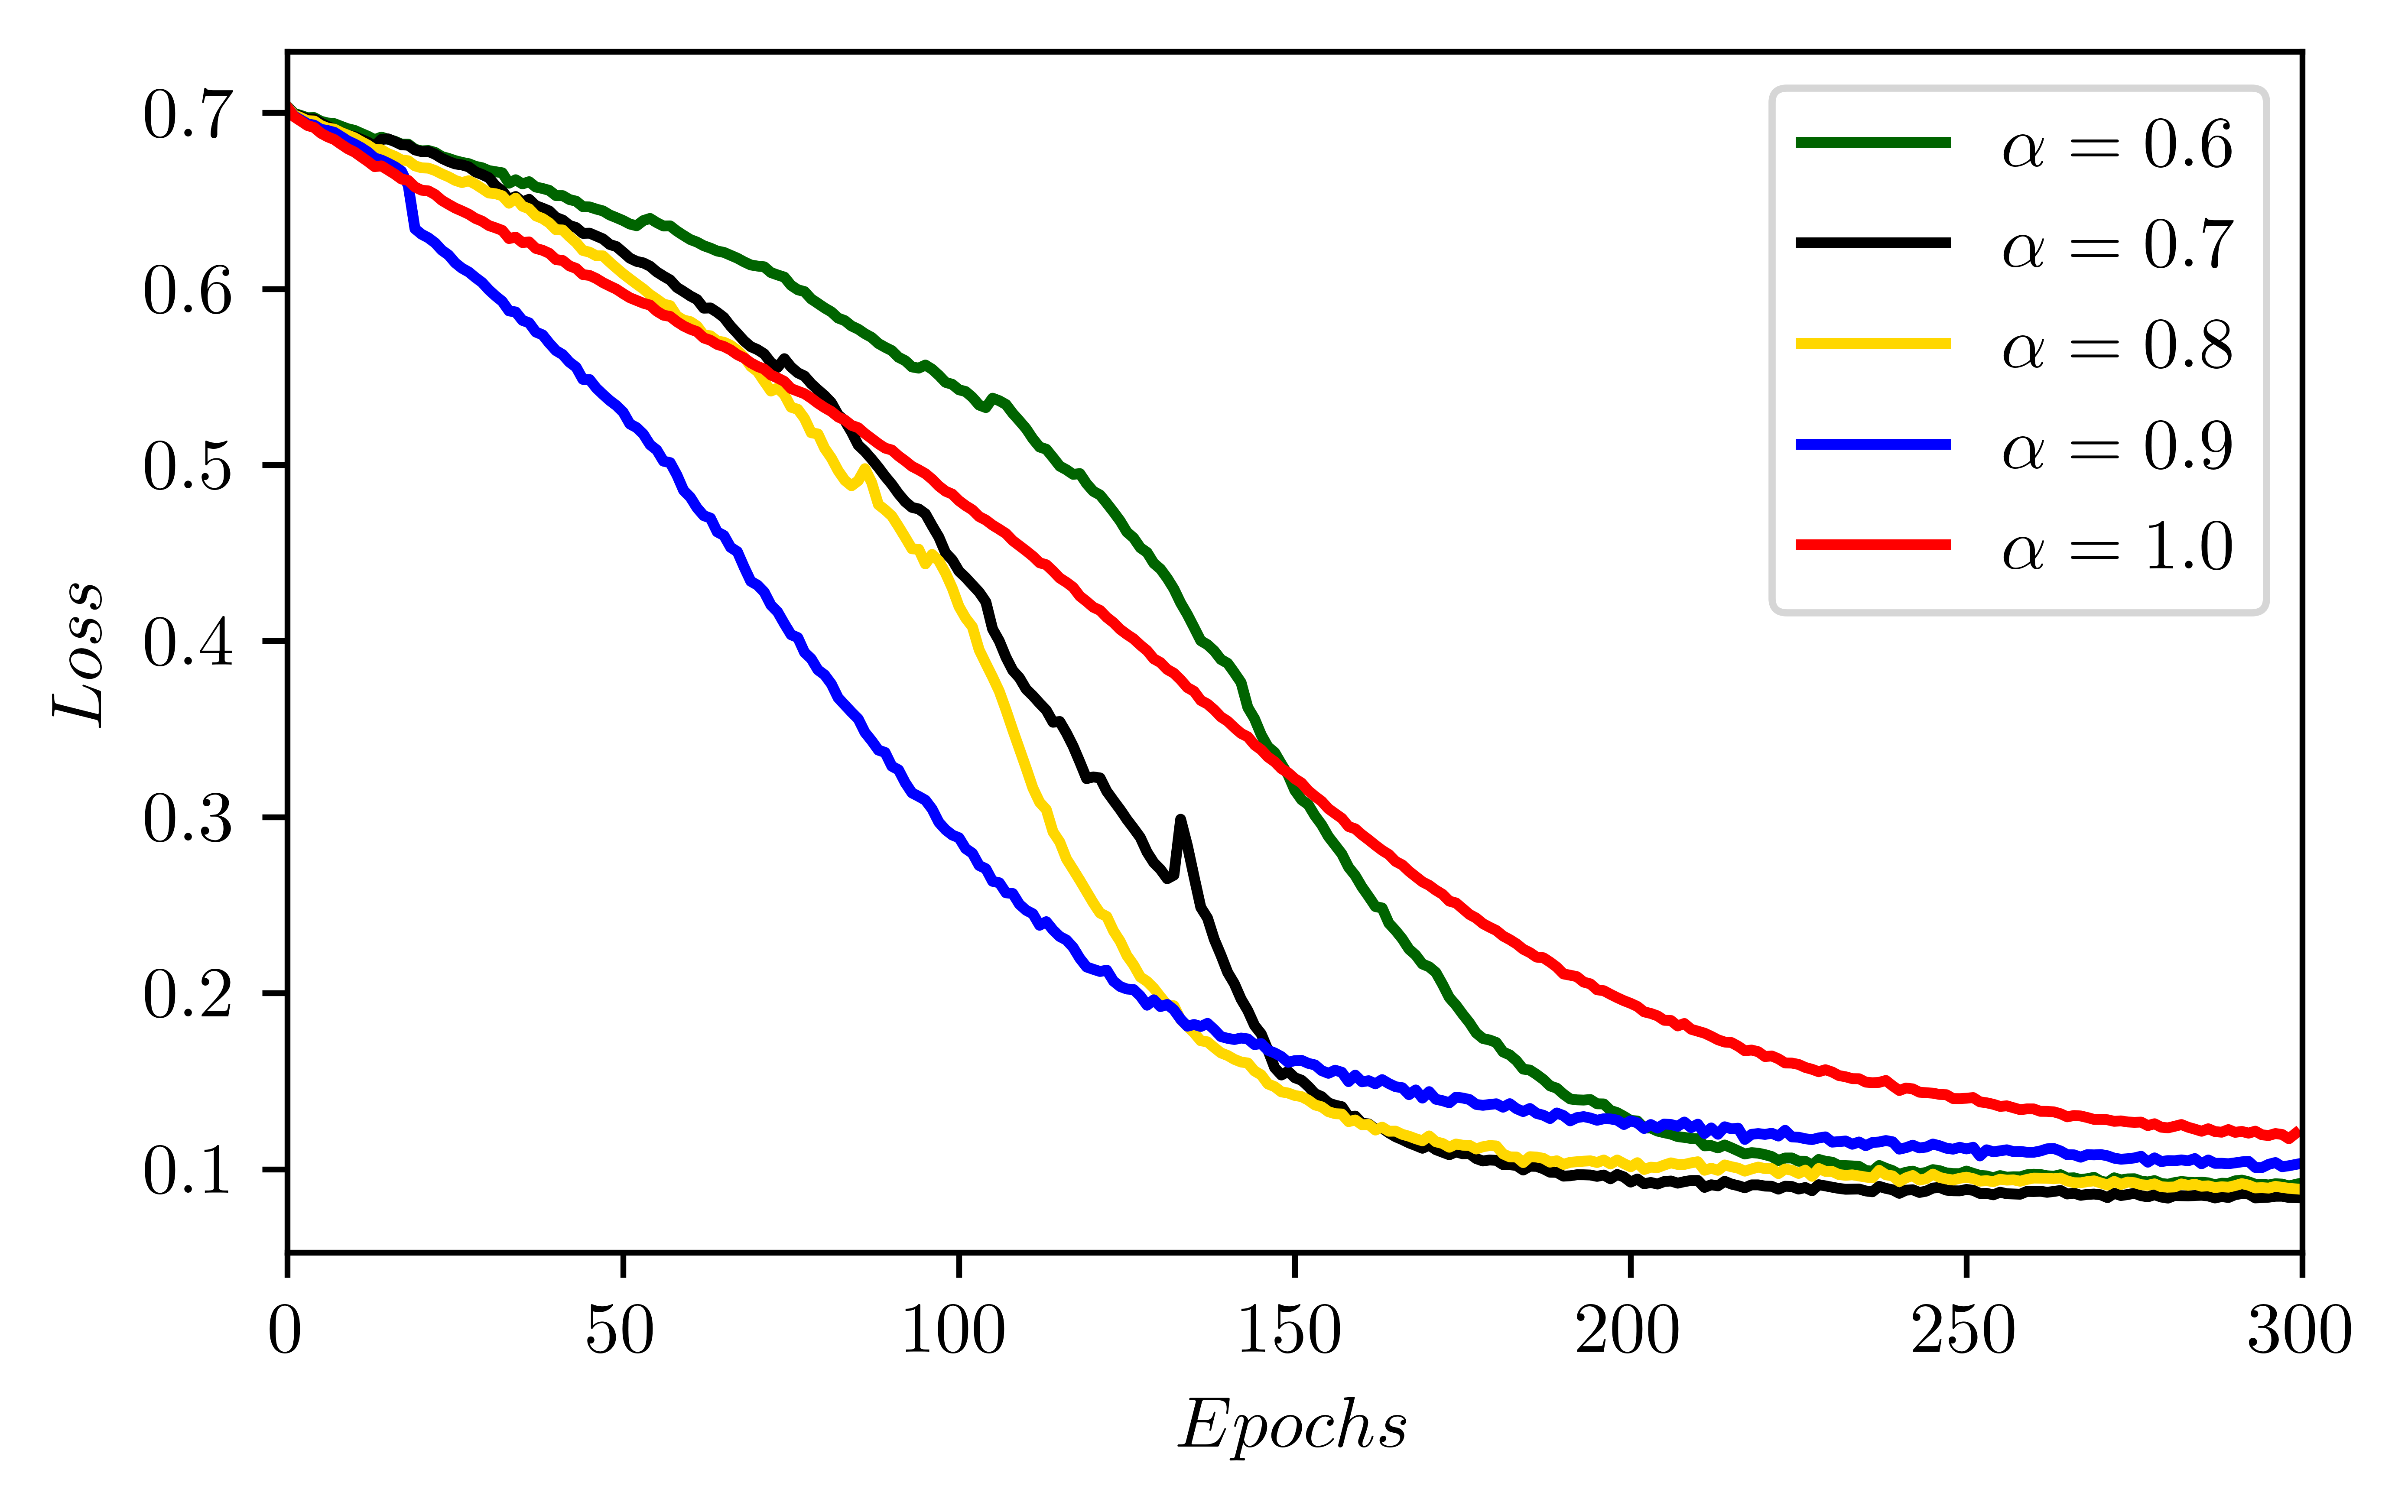

In [162]:
plt.figure(figsize=(5,3),dpi=1200)   #1200
plt.plot(train_loss06,c='darkgreen',label=r'$\alpha=0.6$')
plt.plot(train_loss07,c='k',label=r'$\alpha=0.7$')
plt.plot(train_loss08,c='gold',label=r'$\alpha=0.8$')
plt.plot(train_loss09,c='b',label=r'$\alpha=0.9$')
plt.plot(train_loss10,c='r',label=r'$\alpha=1.0$')
plt.xlim(0,300)
# plt.ylim(0.7,2)
plt.xlabel('$Epochs$')
plt.ylabel('$Loss$')
plt.legend()
# plt.savefig('picture/fig4_a.svg',bbox_inches='tight',format='svg')
# plt.savefig('picture/fig4_a.pdf',bbox_inches='tight',format='pdf')
plt.show()

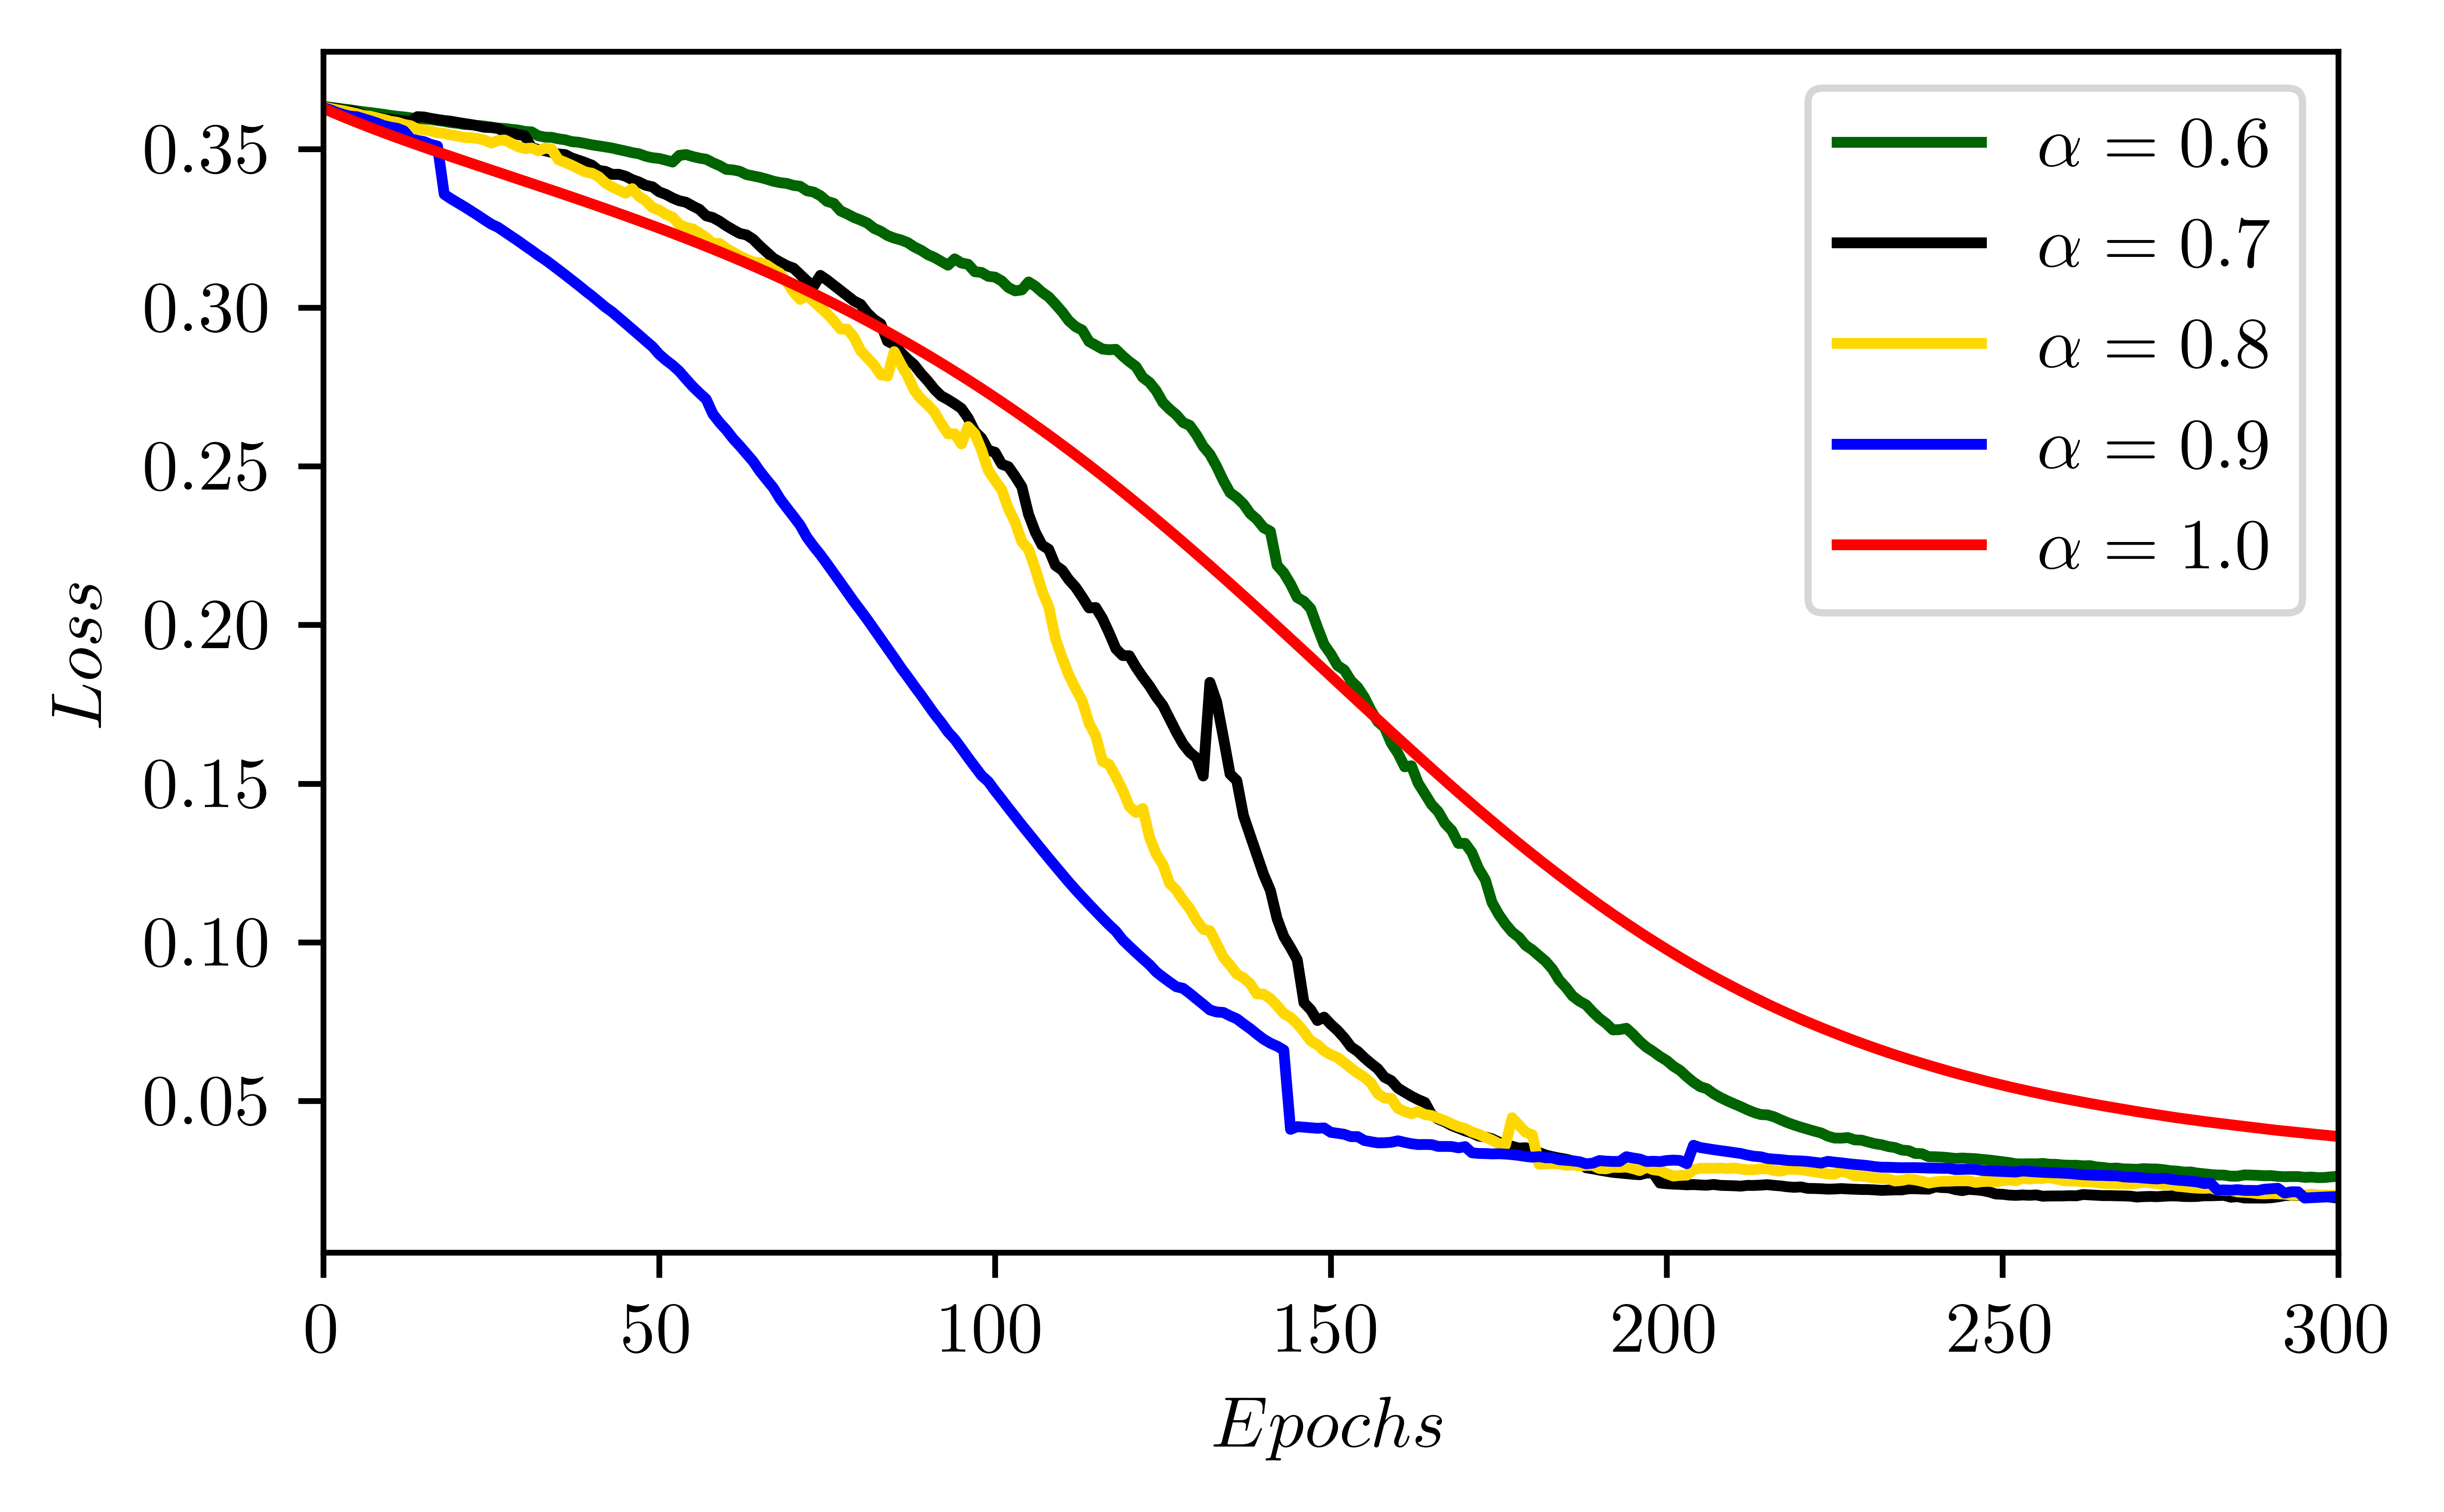

In [163]:
plt.figure(figsize=(5,3),dpi=1200)   #1200
plt.plot(val_loss06,c='darkgreen',label=r'$\alpha=0.6$')
plt.plot(val_loss07,c='k',label=r'$\alpha=0.7$')
plt.plot(val_loss08,c='gold',label=r'$\alpha=0.8$')
plt.plot(val_loss09,c='b',label=r'$\alpha=0.9$')
plt.plot(val_loss10,c='r',label=r'$\alpha=1.0$')
plt.xlim(0,300)
# plt.ylim(0.02,0.1)
plt.xlabel('$Epochs$')
plt.ylabel('$Loss$')
plt.legend()
# plt.savefig('picture/fig4_e.svg',bbox_inches='tight',format='svg')
# plt.savefig('picture/fig4_e.pdf',bbox_inches='tight',format='pdf')
plt.show()

In [166]:
model.load_state_dict(torch.load('./model/'+stock+'_model_fractional_1_0_384.pth'))  ##
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
RMSE10 = RMSE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
MAE10 = MAE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
MAPE10 = MAPE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
print('RMSE:',RMSE10)
print('MAE:',MAE10)
print('MAPE:',MAPE10)

RMSE: 0.30399188
MAE: 0.2682415
MAPE: 0.5108389


In [167]:
model.load_state_dict(torch.load('./model/'+stock+'_model_fractional_0_9_384.pth'))  ##
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
RMSE09 = RMSE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
MAE09 = MAE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
MAPE09 = MAPE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
print('RMSE:',RMSE09)
print('MAE:',MAE09)
print('MAPE:',MAPE09)

RMSE: 0.22231817
MAE: 0.18911532
MAPE: 0.3001764


In [168]:
model.load_state_dict(torch.load('./model/'+stock+'_model_fractional_0_8_384.pth'))  ##
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
RMSE08 = RMSE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
MAE08 = MAE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
MAPE08 = MAPE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
print('RMSE:',RMSE08)
print('MAE:',MAE08)
print('MAPE:',MAPE08)

RMSE: 0.23212641
MAE: 0.19853297
MAPE: 0.3208023


In [169]:
model.load_state_dict(torch.load('./model/'+stock+'_model_fractional_0_7_384.pth'))  ##
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
RMSE07 = RMSE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
MAE07 = MAE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
MAPE07 = MAPE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
print('RMSE:',RMSE07)
print('MAE:',MAE07)
print('MAPE:',MAPE07)

RMSE: 0.2318257
MAE: 0.19782208
MAPE: 0.31905958


In [170]:
model.load_state_dict(torch.load('./model/'+stock+'_model_fractional_0_6_384.pth'))  ##
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
RMSE06 = RMSE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
MAE06 = MAE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
MAPE06 = MAPE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
print('RMSE:',RMSE06)
print('MAE:',MAE06)
print('MAPE:',MAPE06)

RMSE: 0.2611738
MAE: 0.22728145
MAPE: 0.38894334


In [172]:
RMSE_ETTh1 = [0.2611738, 0.2318257, 0.23212641, 0.22231817,0.30399188]    ####DJI,ETTh1
MAE_ETTh1 = [0.22728145, 0.19782208, 0.19853297, 0.18911532,0.2682415]
# MAPE_ETTh1 = [0.38894334, 0.31905958, 0.3208023, 0.3001764,0.5108389]
x = [0.6,0.7,0.8,0.9,1.0]

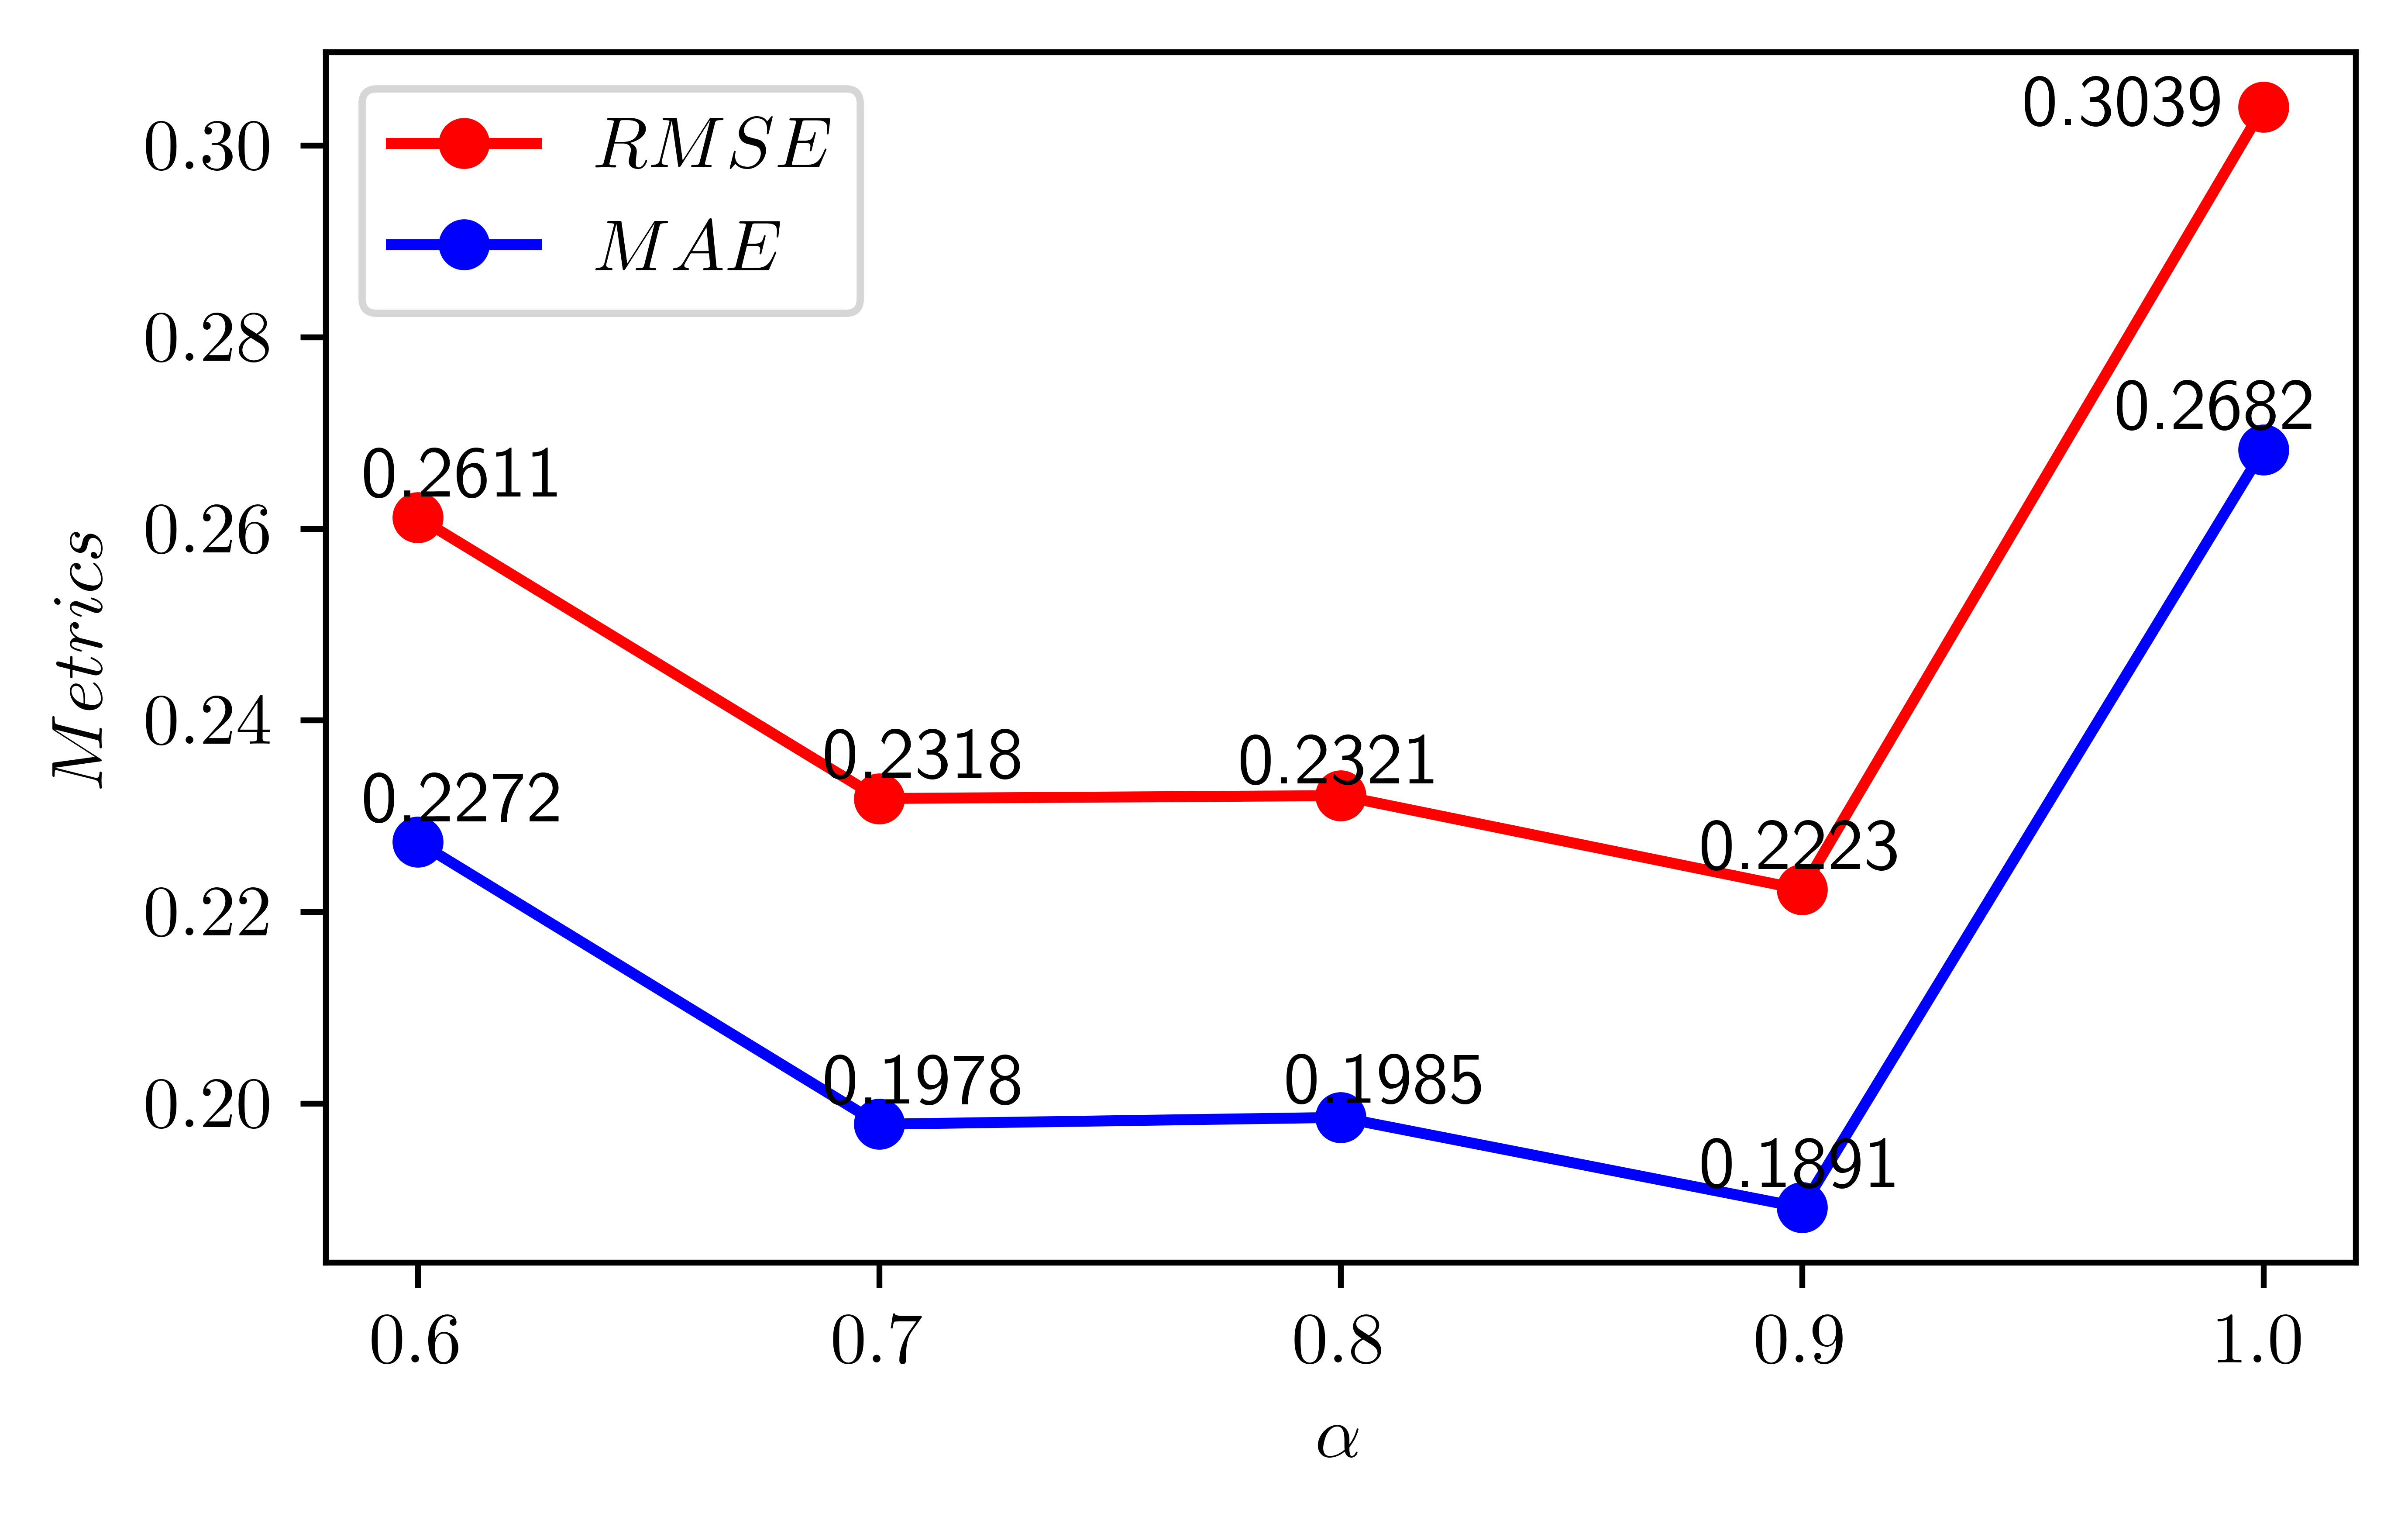

In [182]:
plt.figure(figsize=(5,3),dpi=1200)   #1200

plt.plot(x,RMSE_ETTh1,'o-',c='r',label=r'$RMSE$')
plt.plot(x,MAE_ETTh1,'o-',c='b',label=r'$MAE$')
# plt.plot(x,MAPE_ETTh1,'o-',c='darkgreen',label=r'$MAPE$')

#RMSE
plt.text(0.61, 0.2631738, f'0.2611', ha='center')
plt.text(0.71, 0.2338257, f'0.2318', ha='center')
plt.text(0.8, 0.23322641, f'0.2321', ha='center')
plt.text(0.9, 0.22431817, f'0.2223', ha='center')
plt.text(0.97, 0.30199188, f'0.3039', ha='center')

#MAE
plt.text(0.61, 0.22928145, f'0.2272', ha='center')
plt.text(0.71, 0.19982208, f'0.1978', ha='center')
plt.text(0.81, 0.19993297, f'0.1985', ha='center')
plt.text(0.9, 0.19111532, f'0.1891', ha='center')
plt.text(0.99, 0.2702415, f'0.2682', ha='center')

# #MAPE
# plt.text(0.61, 0.39894334, f'0.3889', ha='center')
# plt.text(0.71, 0.32905958, f'0.3190', ha='center')
# plt.text(0.81, 0.3308023, f'0.3208', ha='center')
# plt.text(0.9, 0.3101764, f'0.3001', ha='center')
# plt.text(0.97, 0.5008389, f'0.5108', ha='center')

plt.xticks(x)
plt.ylabel('$Metrics$')
plt.xlabel(r'$\alpha$')
plt.legend()
plt.savefig('picture/Fig4_c.svg',bbox_inches='tight',format='svg')
plt.savefig('picture/Fig4_c.pdf',bbox_inches='tight',format='pdf')
plt.show()